In [2]:
# conda create -n celloracle_env python=3.10
# conda activate celloracle_env
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import glob
import joblib
from celloracle.applications import Gradient_calculator
from celloracle.applications import Oracle_development_module

In [3]:
import celloracle as co
co.__version__

'0.20.0'

In [4]:
general_palette = ['#118AB2','#06d6a0','#EF476F','#ffd166']

In [5]:
storage =  '/mnt/vstor/SOM_PATH_DKB50/members/rxr456/gdT_celloracle'
os.chdir(storage)

In [6]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
plt.rcParams.update({'font.size': 12, 'font.weight': 'bold','axes.linewidth':2,'savefig.dpi': 300})
# plt.rcParams['figure.figsize'] = [6, 4.5]
# plt.rcParams["savefig.dpi"] = 300
save_folder = "figures"
os.makedirs(save_folder, exist_ok=True)

In [75]:
SCENIC_result = pd.read_csv('/home/rxr456/Github/thesis/SCENIC/rss_general_celltype_cancer_only.csv', index_col=0).T
SCENIC_TF =[i.replace("(+)", "") for i in SCENIC_result.index]

In [7]:
base_GRN = co.data.load_human_promoter_base_GRN()

Loading prebuilt promoter base-GRN. Version: hg19_gimmemotifsv5_fpr2


In [ ]:
links = joblib.load("CRCgdT_oracle_links.pkl")

In [8]:
oracle = co.load_hdf5("CRC_gdT.celloracle.oracle")

### get oracle object ready

In [77]:
adata = sc.read_h5ad("gdT_integrated.h5ad")

In [78]:
adata = adata[adata.obs['tissue']=='Carcinoma']

In [79]:
general_type = adata.obs['cell type'].astype(str)
general_type = general_type.replace({r'IL7R.* TRM':'TRM', r'^.*Teff.*':'Teff','^.*Tex.*':'Tex'},regex=True)
adata.obs['general_type'] = general_type

In [80]:
adata = adata[adata.obs['general_type'].isin(['TRM', 'Teff'])].copy()

... storing 'general_type' as categorical


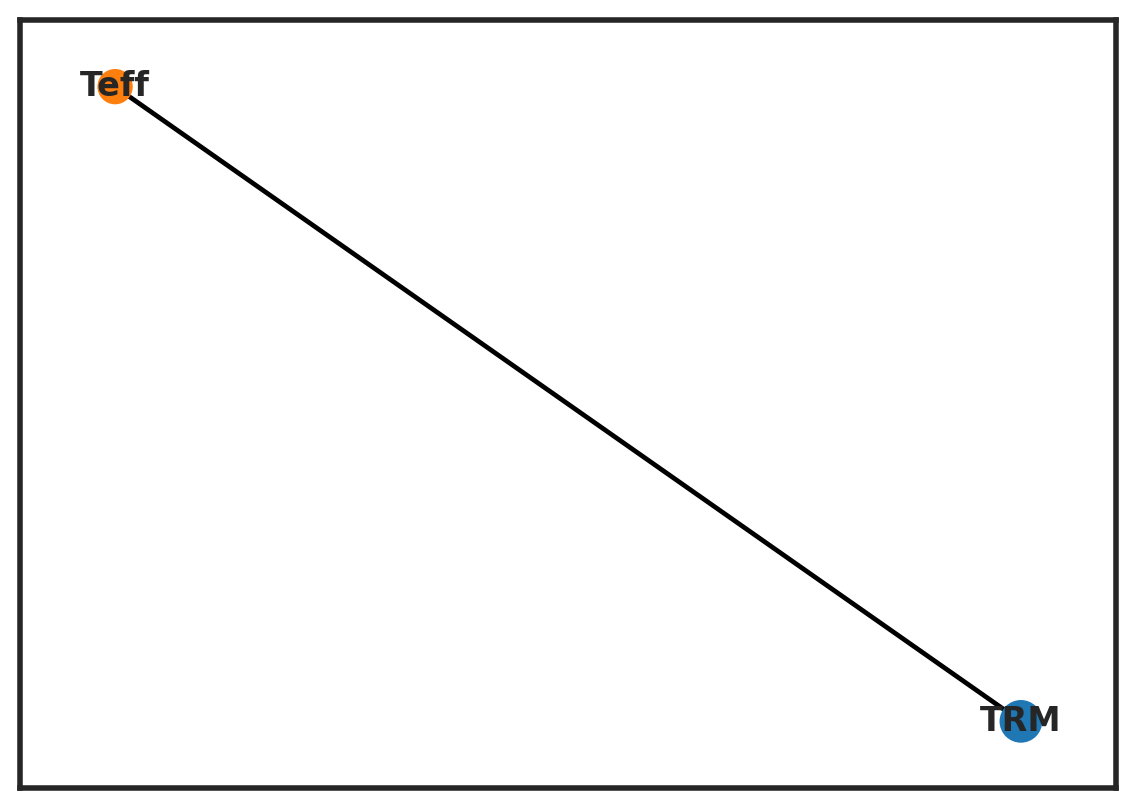

In [81]:
# sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor = 'seurat_v3')
# sc.tl.pca(adata, n_comps=50, svd_solver='arpack', random_state=42)
# sc.pp.neighbors(adata, n_neighbors=30, n_pcs=50, random_state=42)
sc.tl.paga(adata, groups='general_type')
sc.pl.paga(adata, color='general_type')

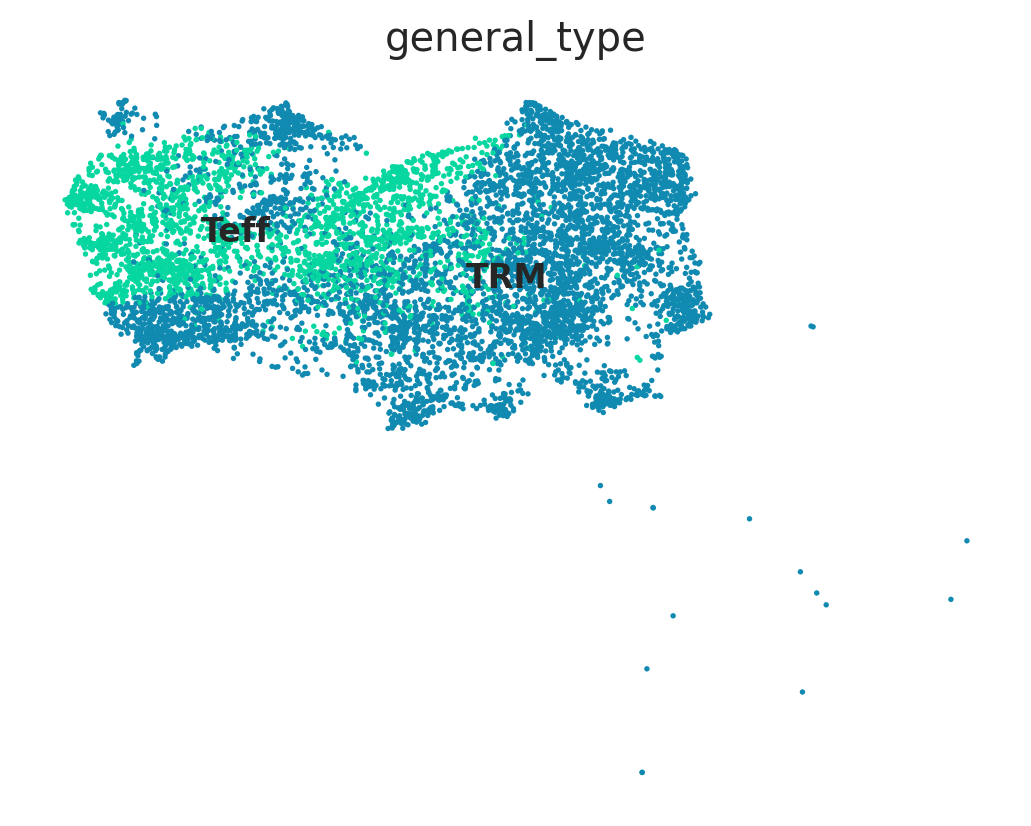

In [87]:
sc.tl.umap(adata, min_dist=0.2, spread=0.6, init_pos='paga', random_state=42)
sc.pl.umap(adata, color='general_type', frameon=False, legend_loc='on data',palette=['#118AB2','#06d6a0'])

In [88]:
sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor = 'seurat_v3')
adata = adata[:,(adata.var['highly_variable']) | (adata.var_names.isin(SCENIC_TF))].copy()

In [89]:
oracle = co.Oracle()
adata.X =adata.layers['counts'].copy()
oracle.import_anndata_as_raw_count(adata=adata,
                                   cluster_column_name="general_type",
                                   embedding_name="X_umap")

In [90]:
oracle.import_TF_data(TF_info_matrix=base_GRN)

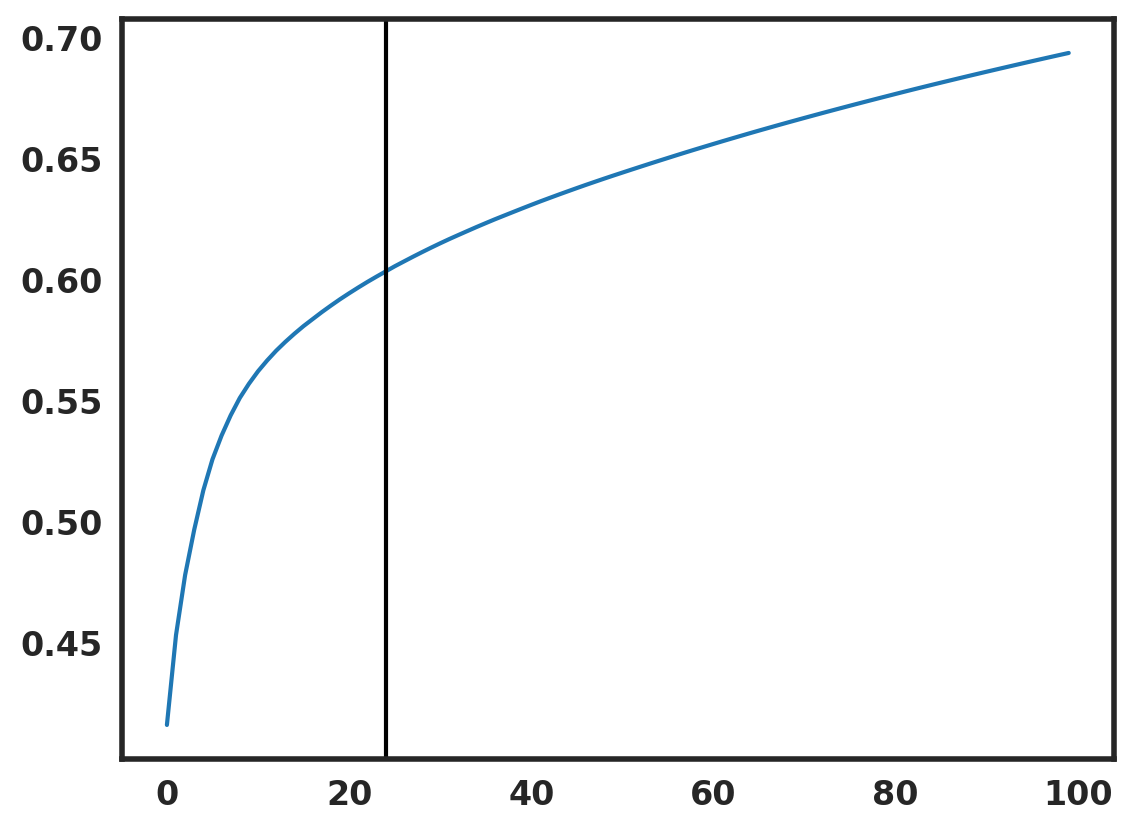

24


In [91]:
oracle.perform_PCA()

# Select important PCs
plt.plot(np.cumsum(oracle.pca.explained_variance_ratio_)[:100])
n_comps = np.where(np.diff(np.diff(np.cumsum(oracle.pca.explained_variance_ratio_))>0.002))[0][0]
plt.axvline(n_comps, c="k")
plt.show()
print(n_comps)
n_comps = min(n_comps, 50)

In [92]:
n_cell = oracle.adata.shape[0]
print(f"cell number is :{n_cell}")

cell number is :7841


In [93]:
k = int(0.025*n_cell)
print(f"Auto-selected k is :{k}")

Auto-selected k is :196


In [94]:
oracle.knn_imputation(n_pca_dims=n_comps, k=k, balanced=True, b_sight=k*8,
                      b_maxl=k*4, n_jobs=4)
oracle.to_hdf5("CRC_gdT.celloracle.oracle")

In [95]:
oracle.adata

AnnData object with n_obs × n_vars = 7841 × 3046
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'patient', 'tissue', 'gender', 'age', 'site', 'TNM_T', 'TNM_N', 'TNM_M', 'stage', 'percent.mt', 'n_counts', 'n_genes', 'mt_frac', 'ribo_frac', 'leiden', 'leiden2', 'leiden3', 'leiden4', 'leiden5', 'clusters_blind', 'cluster_blind', 'leiden6', 'cell type', 'leiden7', 'leiden8', 'leiden9', 'leiden10', 'leiden11', 'general_type'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'symbol', 'isin_top1000_var_mean_genes', 'isin_TFdict_targets', 'isin_TFdict_regulators'
    uns: 'TNM_M_colors', 'TNM_N_colors', 'TNM_T_colors', 'cell type_colors', 'cell type_sizes', 'cluster_blind_colors', 'clusters_blind_colors', 'gender_colors', 'leiden', 'leiden10_colors', 'leiden11_colors', 'leiden2_colors', 'leiden3_colors', 'leiden4_colors', 'leiden5_colors', 'leiden6_colors', 'leiden7_colors', 'leiden8_colors', 'leiden9_colors', 'leiden_colors', 'neighbors', 'orig

### compute links

In [96]:
links = oracle.get_links(cluster_name_for_GRN_unit="general_type", alpha=10,
                         verbose_level=10, n_jobs = 20)
joblib.dump(links, "CRCgdT_oracle_links.pkl")

  0%|          | 0/2 [00:00<?, ?it/s]

Inferring GRN for TRM...


  0%|          | 0/1997 [00:00<?, ?it/s]

Inferring GRN for Teff...


  0%|          | 0/1997 [00:00<?, ?it/s]

['CRCgdT_oracle_links.pkl']

In [97]:
links.filter_links(p=0.001, weight="coef_abs", threshold_number=2000)

TRM


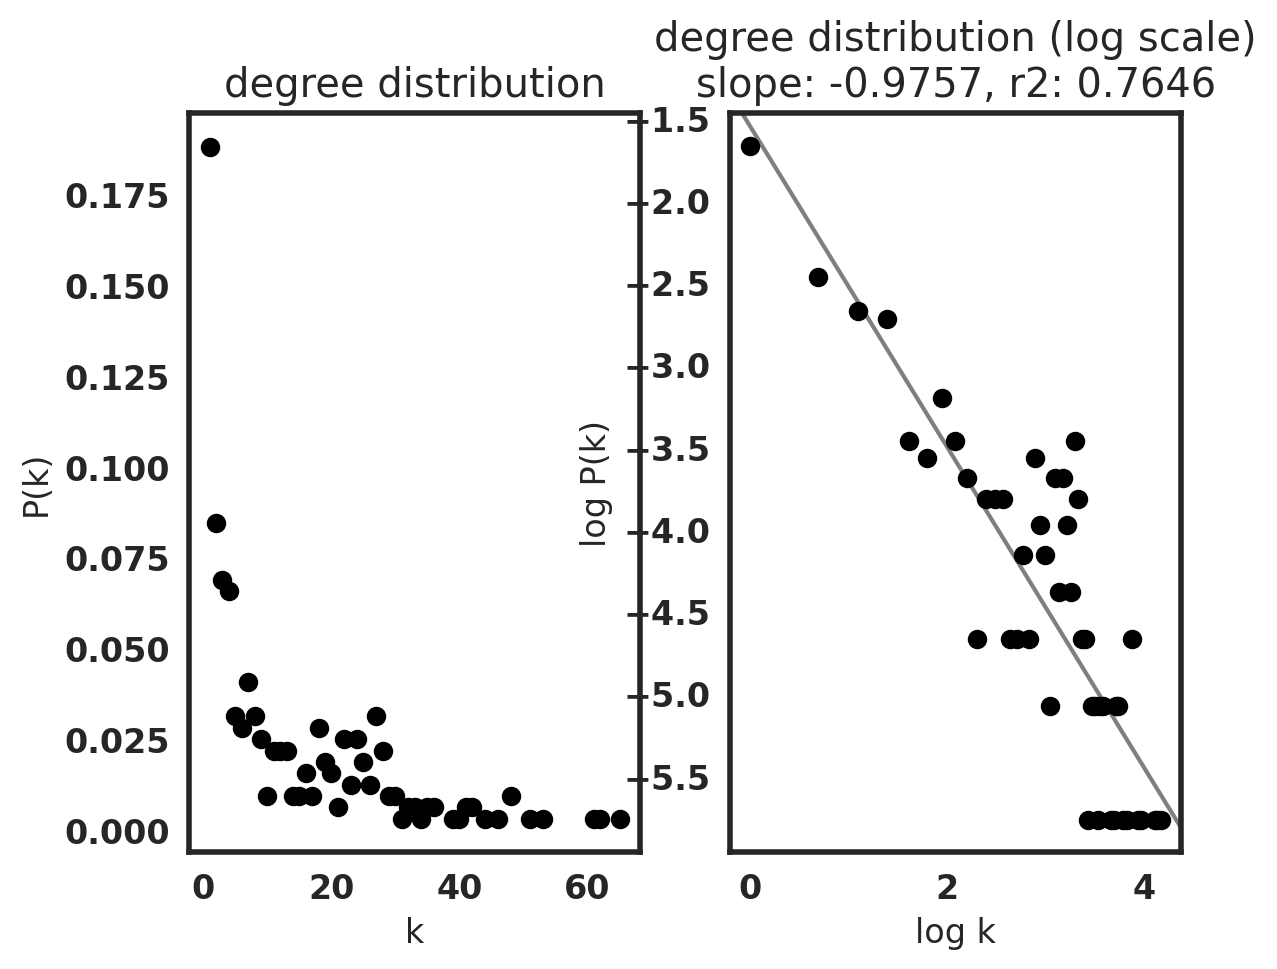

Teff


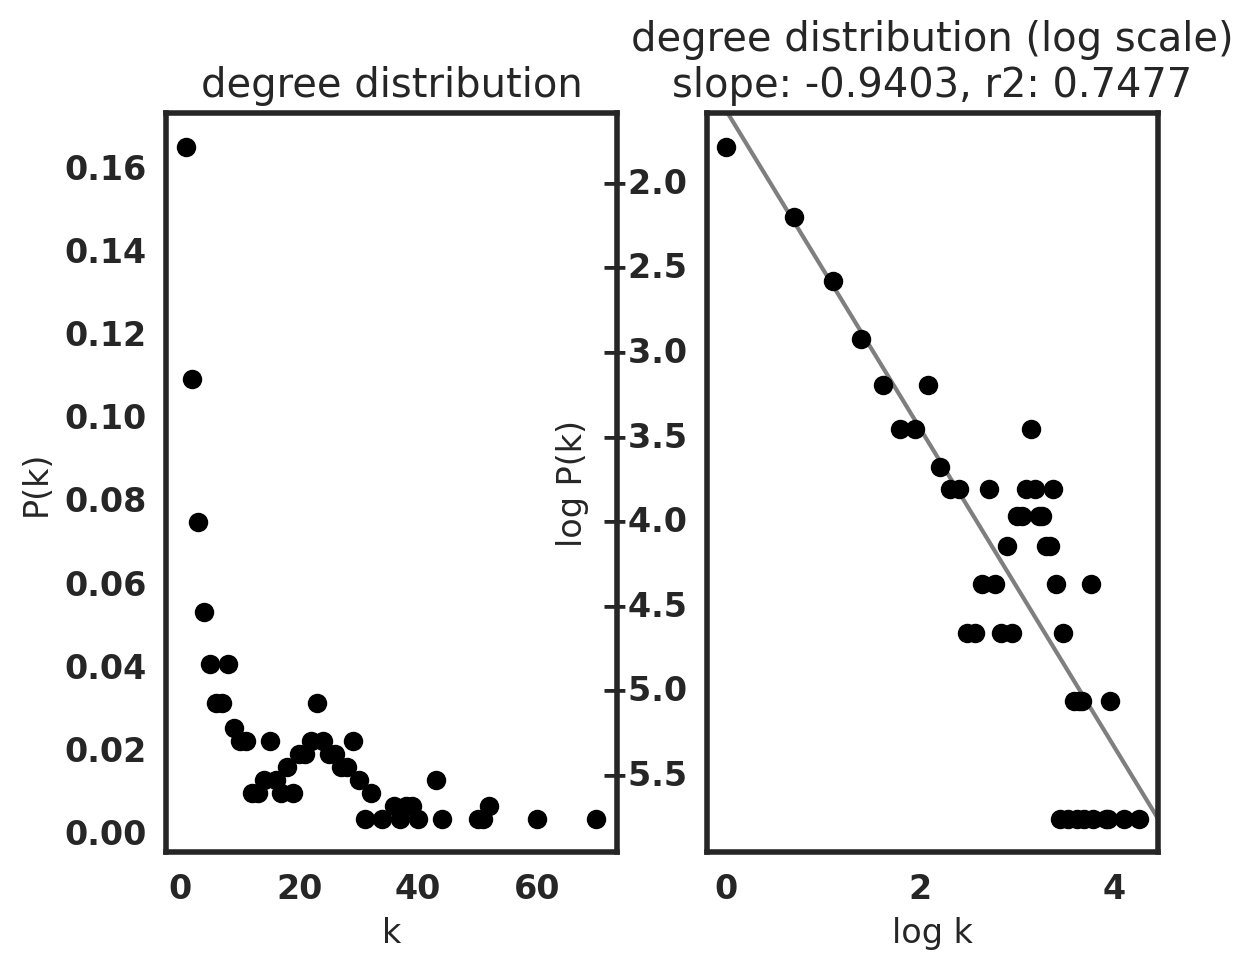

In [98]:
links.plot_degree_distributions(plot_model=True,
                                               #save=f"{save_folder}/degree_distribution/",
                                               )

In [99]:
links.get_network_score()
links.merged_score.head()

,degree_all,degree_centrality_all,degree_in,degree_centrality_in,degree_out,degree_centrality_out,betweenness_centrality,eigenvector_centrality,cluster
YY1,62,0.194969,0,0.000000,62,0.194969,0.0,1.000000,TRM
RPL34,15,0.047170,15,0.047170,0,0.000000,0.0,0.253331,TRM
EOMES,13,0.040881,0,0.000000,13,0.040881,0.0,0.245549,TRM
NR4A2,15,0.047170,4,0.012579,11,0.034591,112.0,0.218264,TRM
RPL27A,21,0.066038,21,0.066038,0,0.000000,0.0,0.195316,TRM


In [100]:
joblib.dump(links, "CRCgdT_oracle_links.pkl")

['CRCgdT_oracle_links.pkl']

In [101]:
links.filter_links()
oracle.get_cluster_specific_TFdict_from_Links(links_object=links)
oracle.fit_GRN_for_simulation(alpha=10,
                              use_cluster_specific_TFdict=True)

  0%|          | 0/2 [00:00<?, ?it/s]

In [102]:
total_TF = set()
for i in links.links_dict.keys():
    total_TF = total_TF.union(set(links.links_dict[i]['source'].unique()))

In [103]:
# oracle.predictive_GRN
# dir(oracle)
# links.links_dict
# here is where the edge information stored: oracle.coef_matrix_per_cluster
total_to_TF = list()
for col in ['TRM', 'Teff']:
    topTF = SCENIC_result[col].sort_values(ascending=False).index[0:5].tolist()
    topTF = [i.replace("(+)", "") for i in topTF]
    total_to_TF.extend(topTF)
total_to_TF = set(total_to_TF)
top_tf_each_cluster = total_TF.intersection(total_to_TF)
top_tf_each_cluster

{'ATF3',
 'BHLHE40',
 'ELF1',
 'FOSL2',
 'FOXO1',
 'IKZF1',
 'IRF1',
 'KLF2',
 'NR3C1',
 'XBP1'}

In [104]:

for goi in top_tf_each_cluster:
    print(goi)
    oracle.simulate_shift(perturb_condition={goi: 0.0},
                      n_propagation=3)
    
    oracle.estimate_transition_prob(n_neighbors=200,
                                knn_random=True,
                                sampled_fraction=1)
    oracle.calculate_embedding_shift(sigma_corr=0.05)
    oracle.to_hdf5(goi + "_oracle_shifted.celloracle.oracle")

XBP1
NR3C1
KLF2
FOXO1
ATF3
ELF1
FOSL2
IKZF1
IRF1
BHLHE40


In [105]:
goi = 'KLF2'
oracle_perturb = co.load_hdf5(goi + "_oracle_shifted.celloracle.oracle")

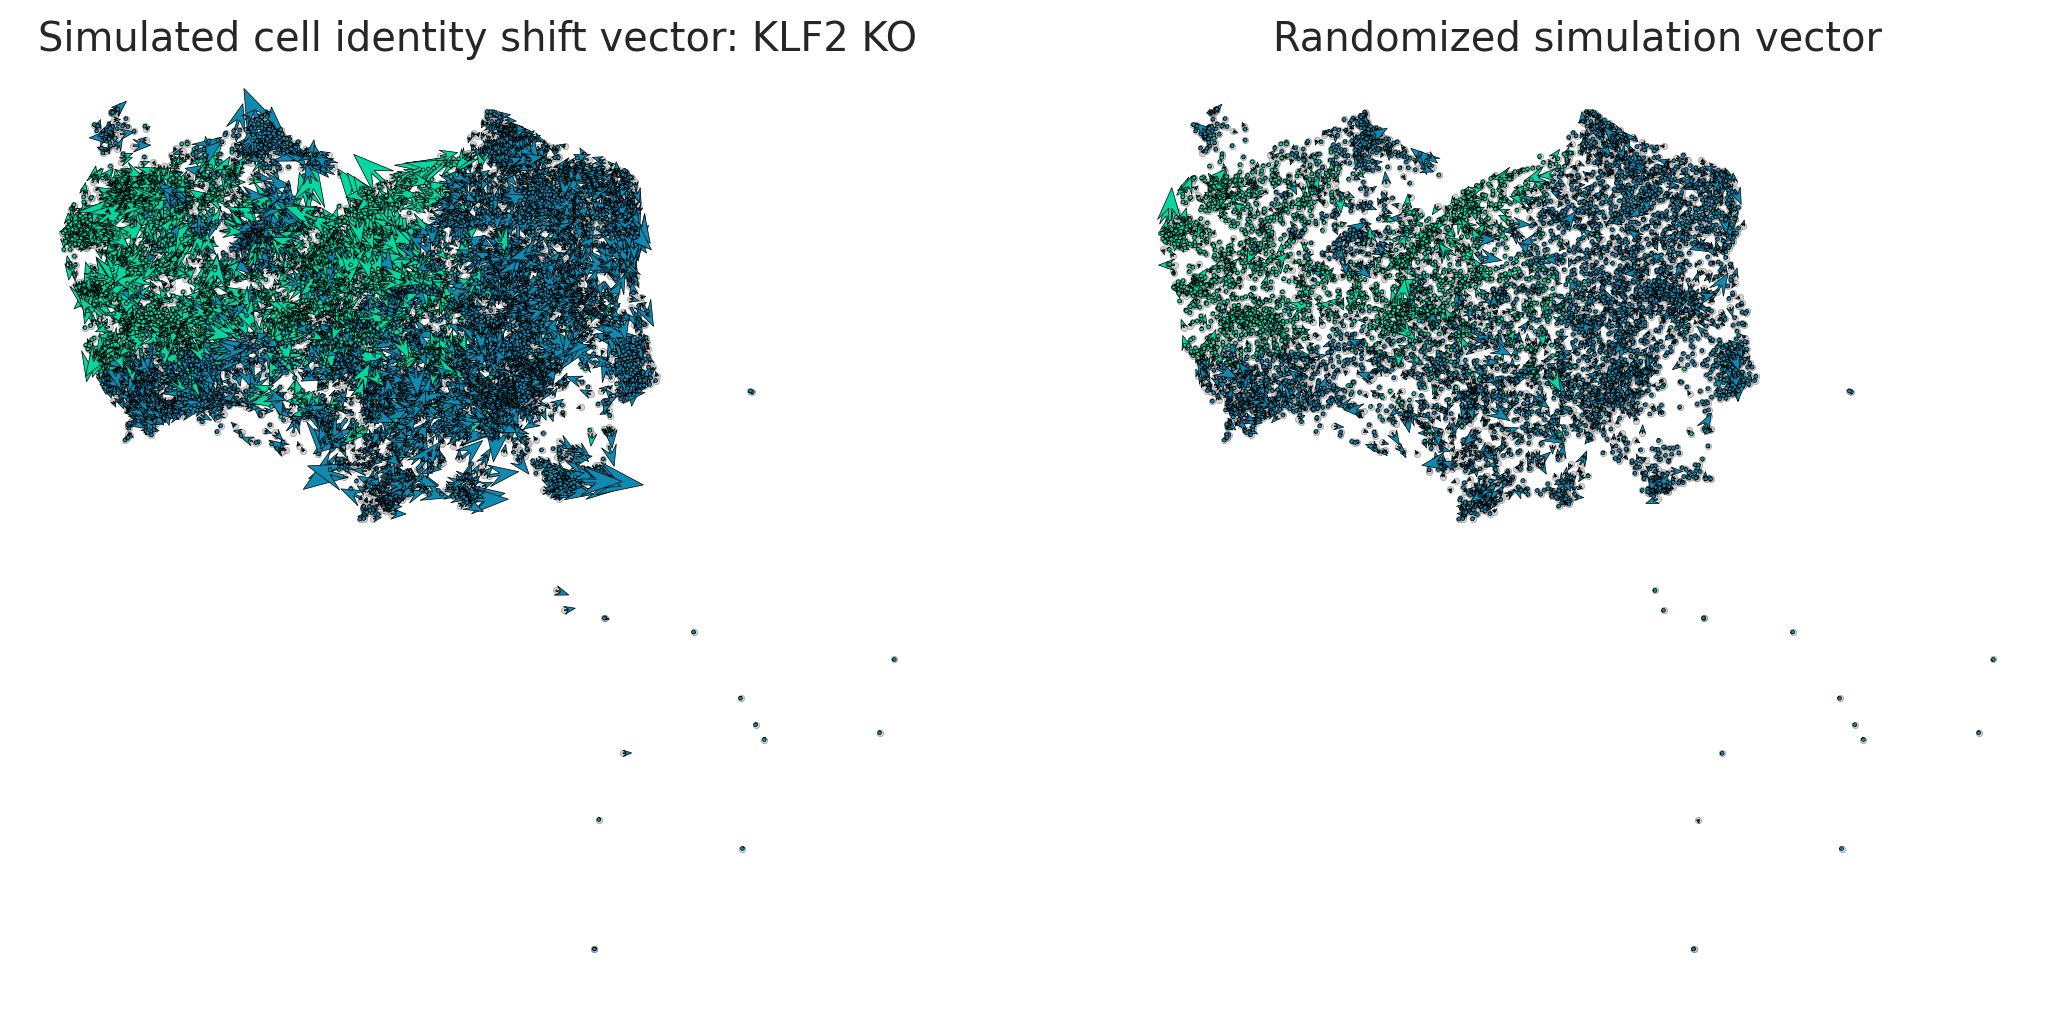

In [106]:
%matplotlib inline

fig, ax = plt.subplots(1, 2,  figsize=[13, 6])
scale = 25
# Show quiver plot
oracle_perturb.plot_quiver(scale=scale, ax=ax[0])
ax[0].set_title(f"Simulated cell identity shift vector: {goi} KO")

# Show quiver plot that was calculated with randomized graph.
oracle_perturb.plot_quiver_random(scale=scale, ax=ax[1])
ax[1].set_title(f"Randomized simulation vector")
fig.savefig(f"{save_folder}/oracle_perturb_quiver_{goi}.pdf", bbox_inches='tight', dpi=300)


In [107]:
n_grid = 40
oracle_perturb.calculate_p_mass(smooth=0.8, n_grid=n_grid, n_neighbors=200)

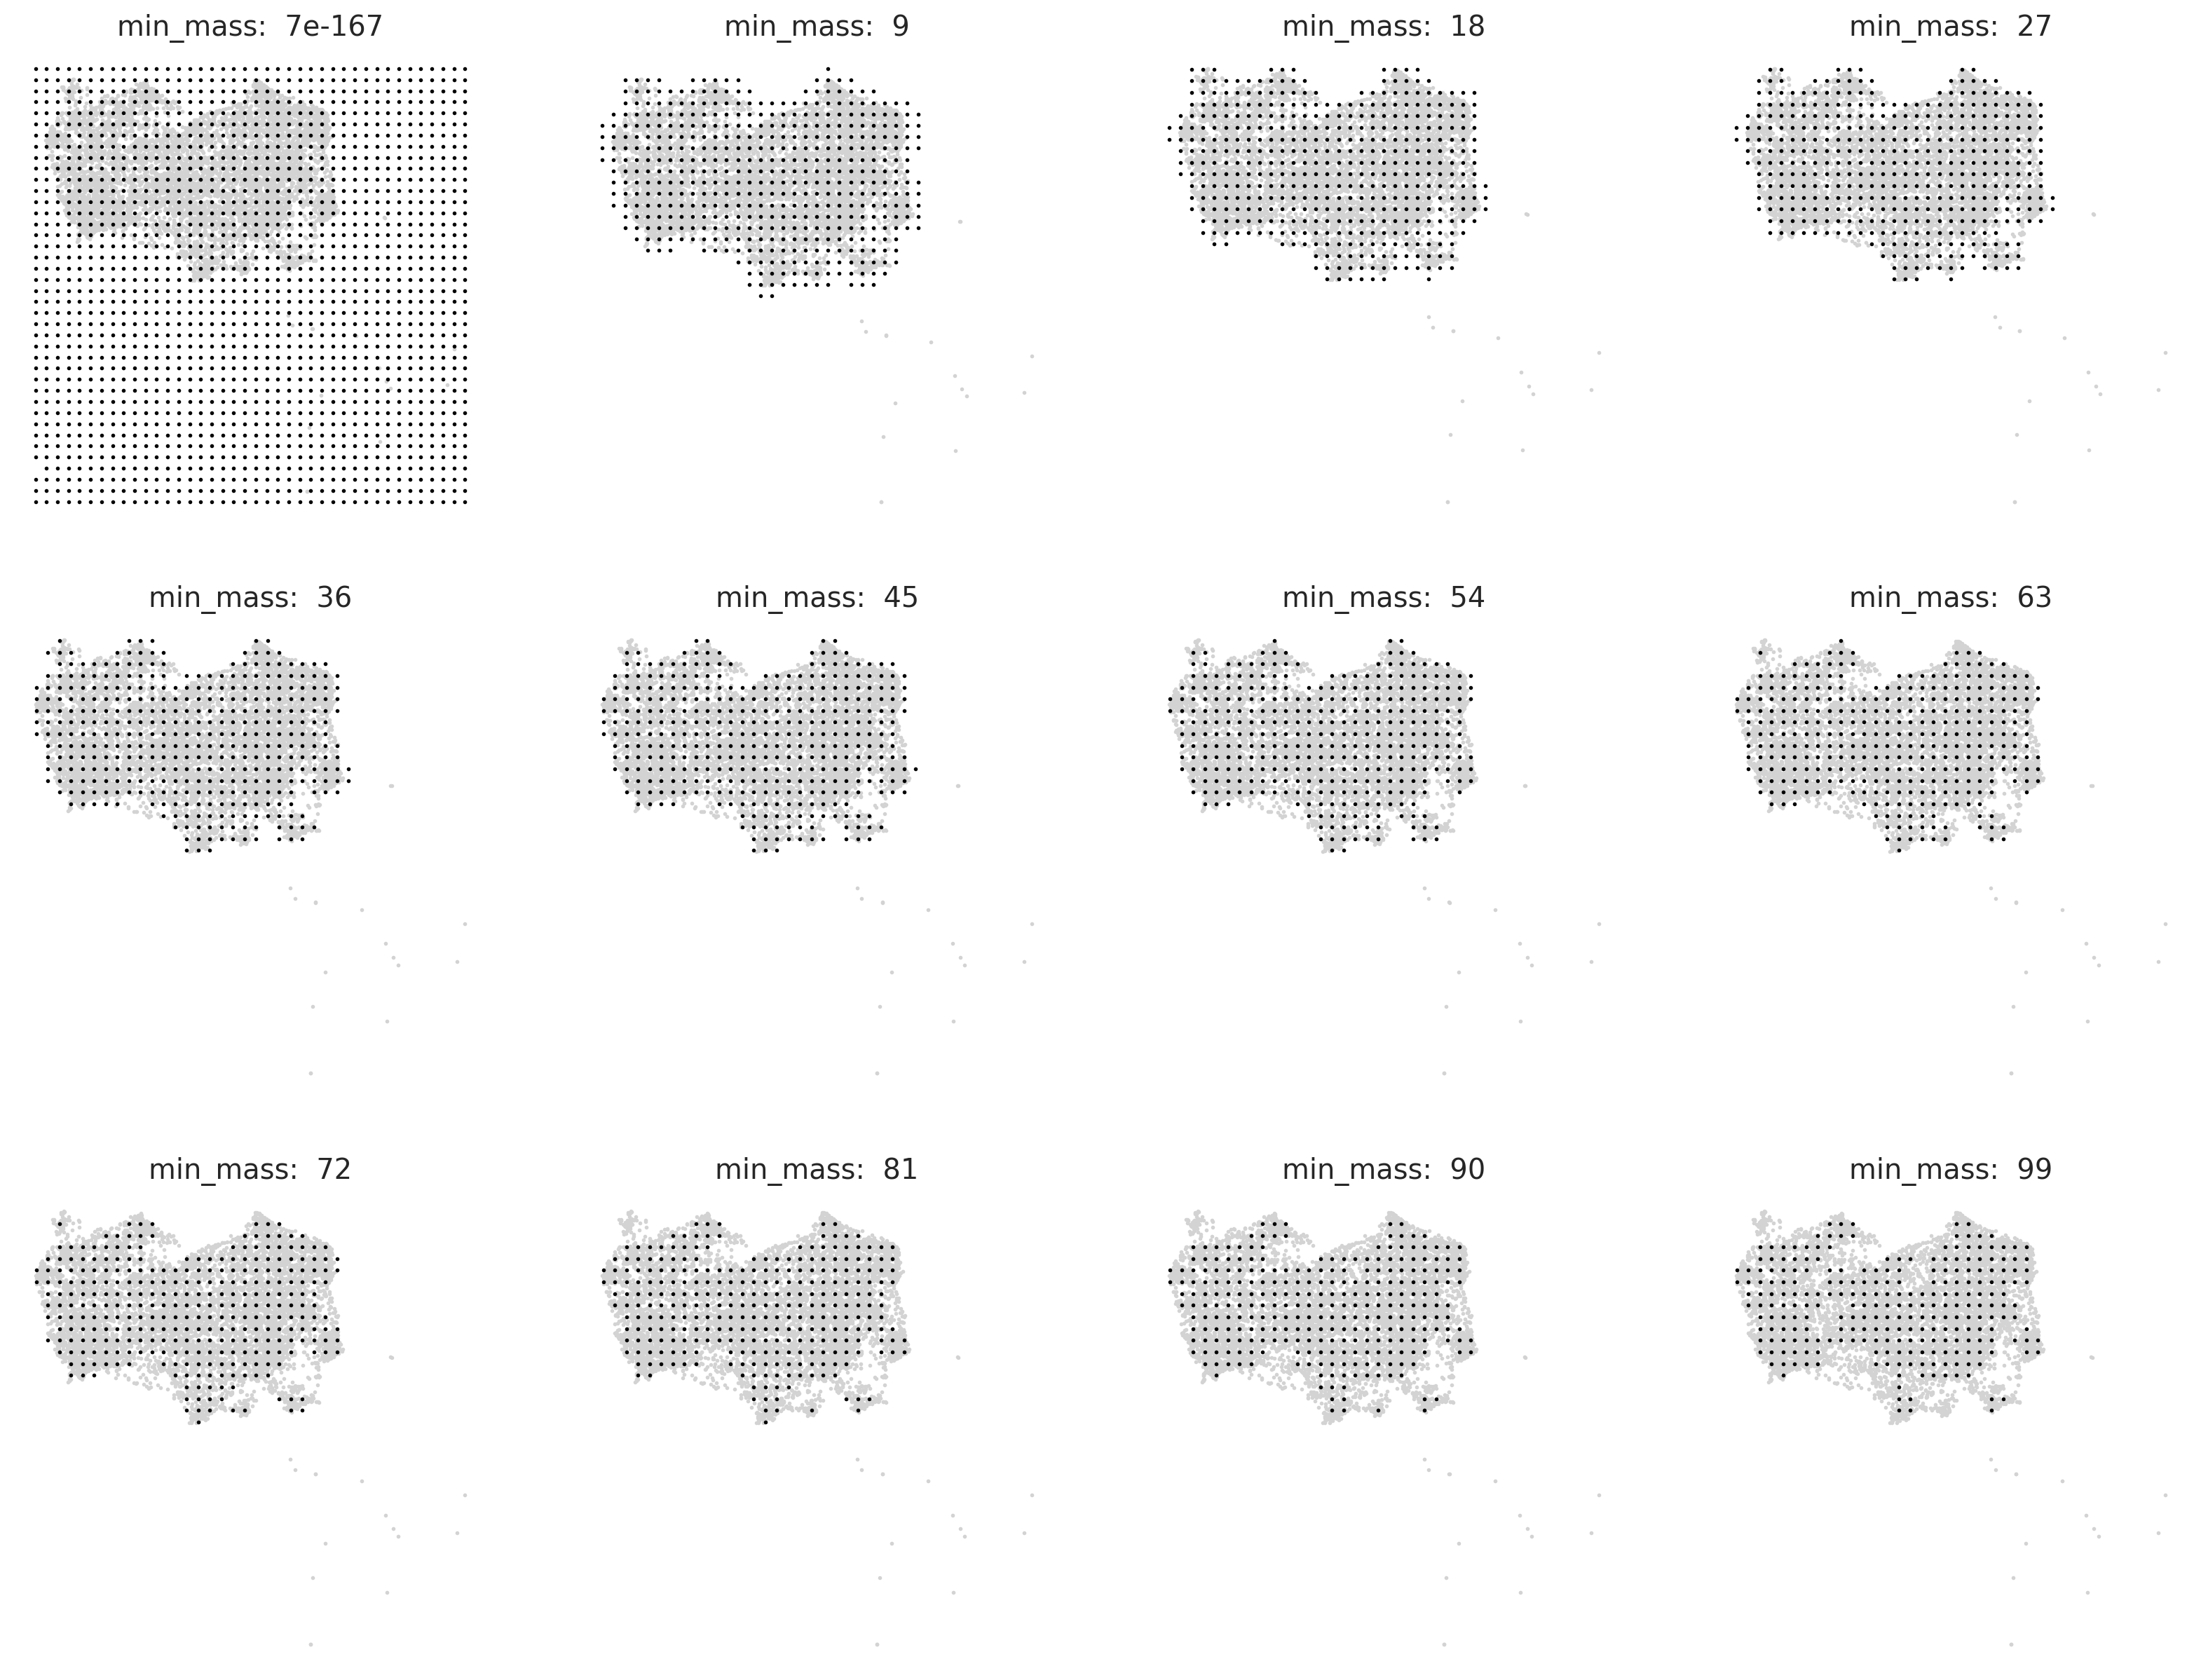

In [108]:
oracle_perturb.suggest_mass_thresholds(n_suggestion=12)

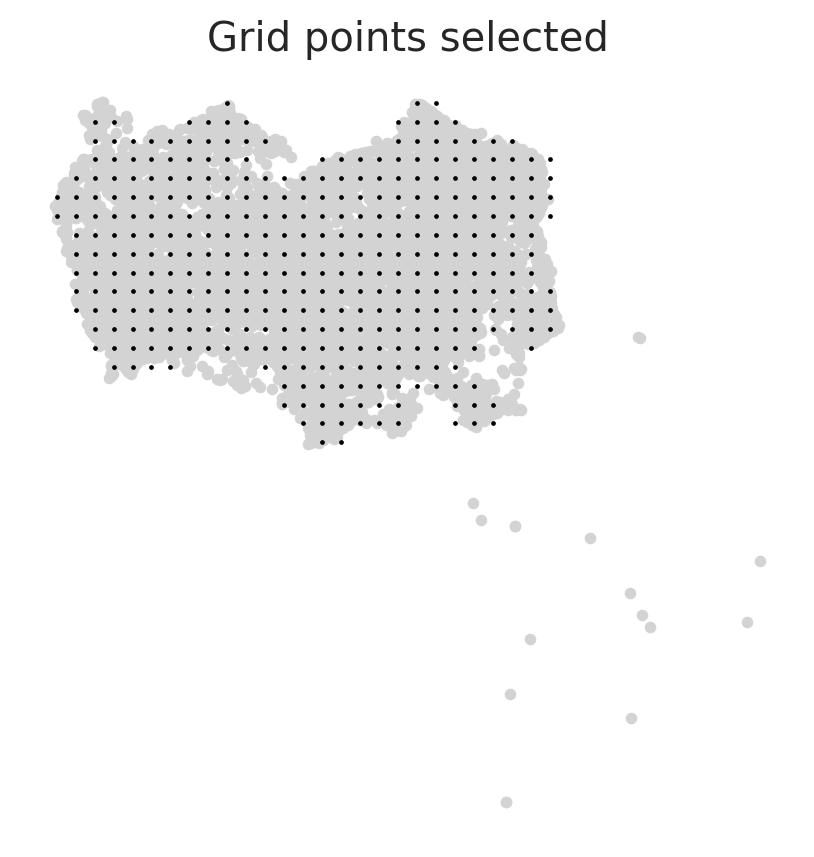

In [109]:
min_mass = 50
oracle_perturb.calculate_mass_filter(min_mass=min_mass, plot=True)

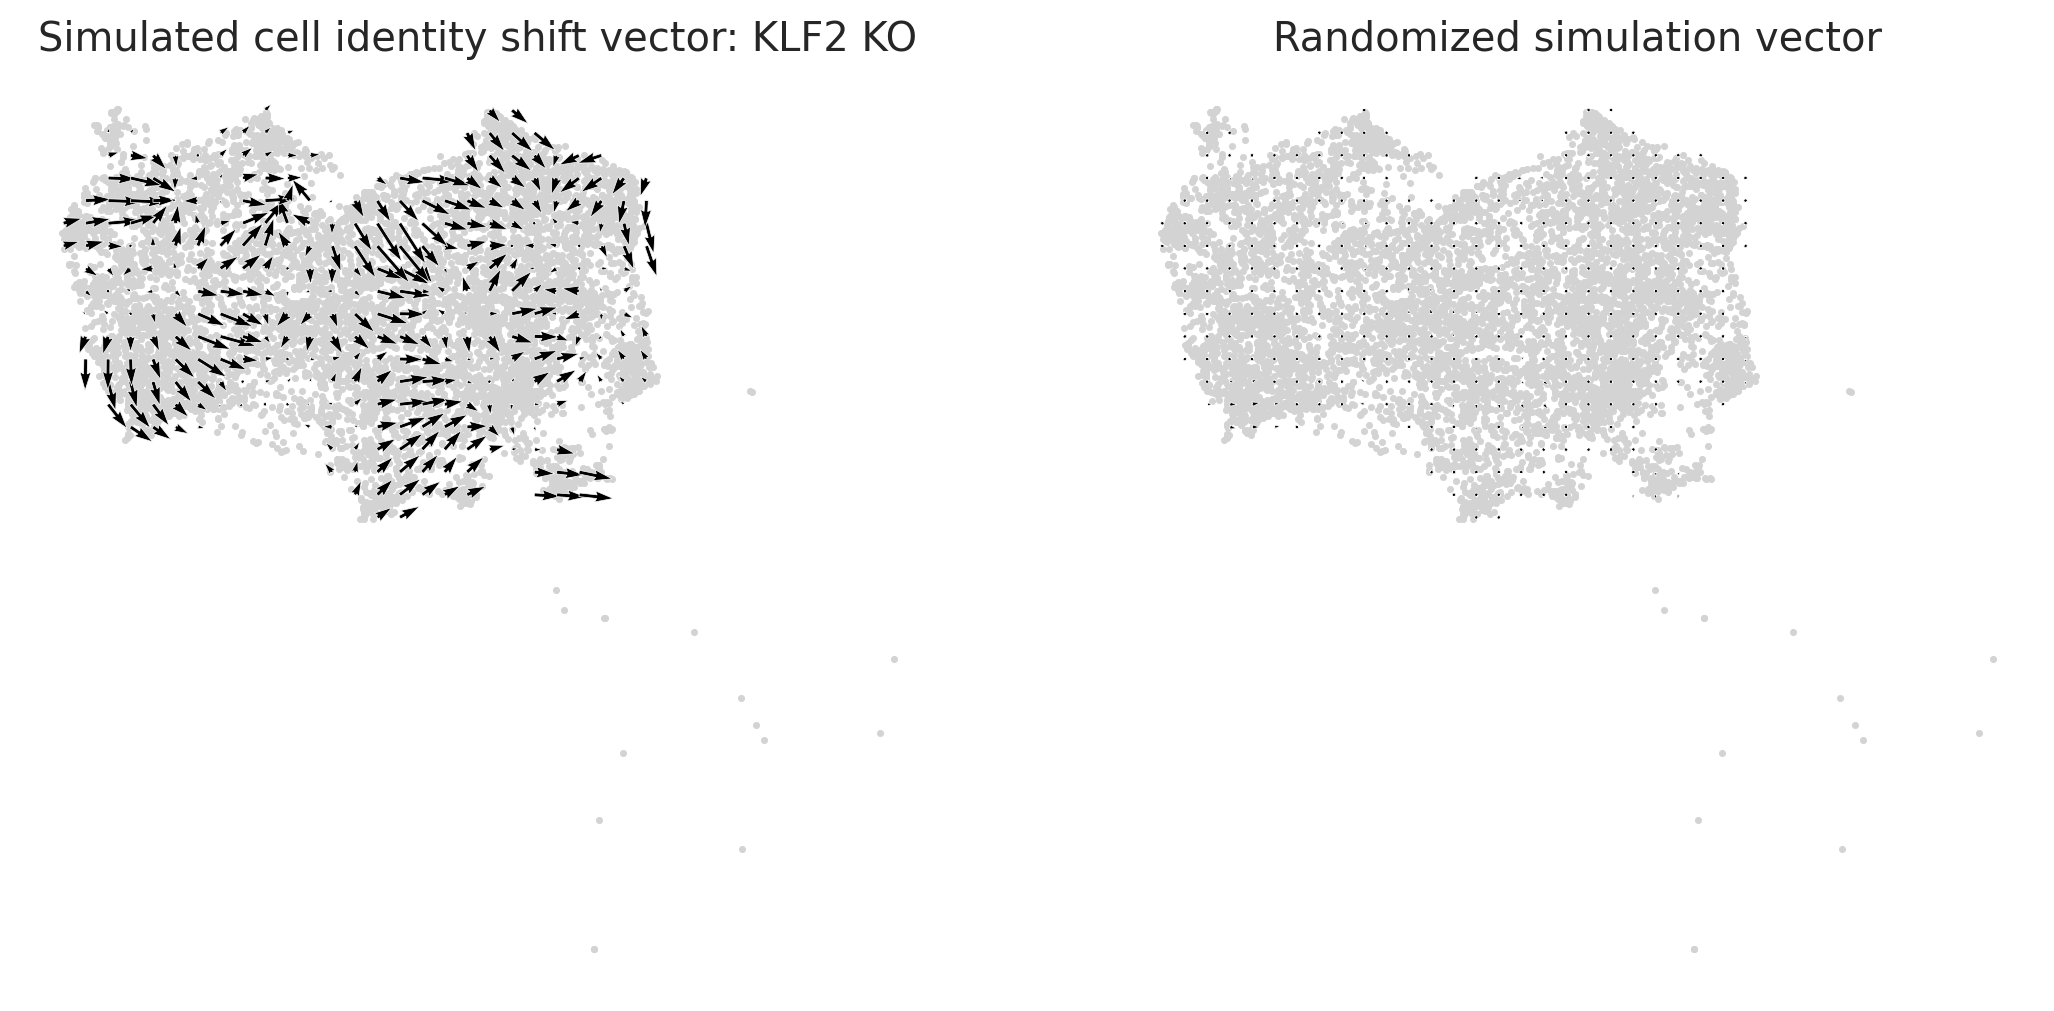

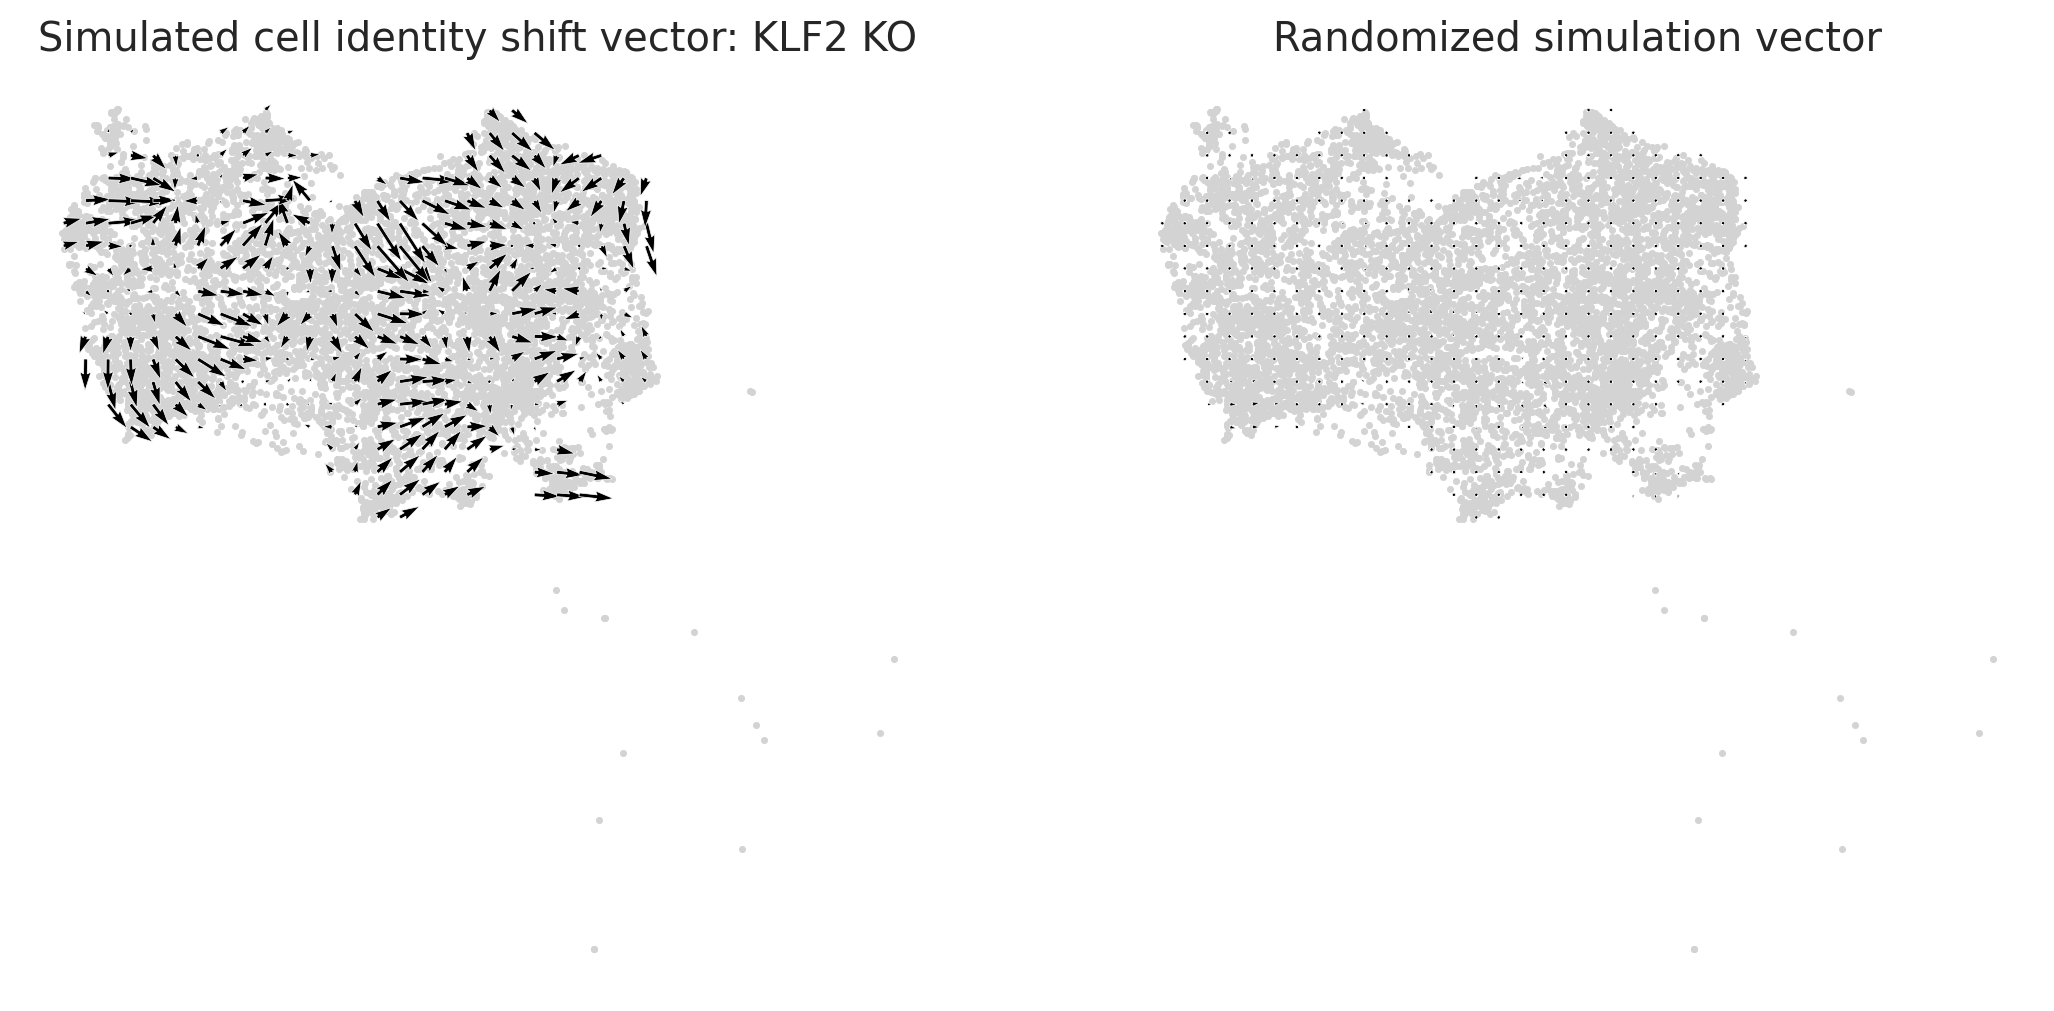

In [111]:
fig, ax = plt.subplots(1, 2,  figsize=[13, 6])

scale_simulation = 7
# Show quiver plot
oracle_perturb.plot_simulation_flow_on_grid(scale=scale_simulation, ax=ax[0])
ax[0].set_title(f"Simulated cell identity shift vector: {goi} KO")

# Show quiver plot that was calculated with randomized graph.
oracle_perturb.plot_simulation_flow_random_on_grid(scale=scale_simulation, ax=ax[1])
ax[1].set_title(f"Randomized simulation vector")

fig

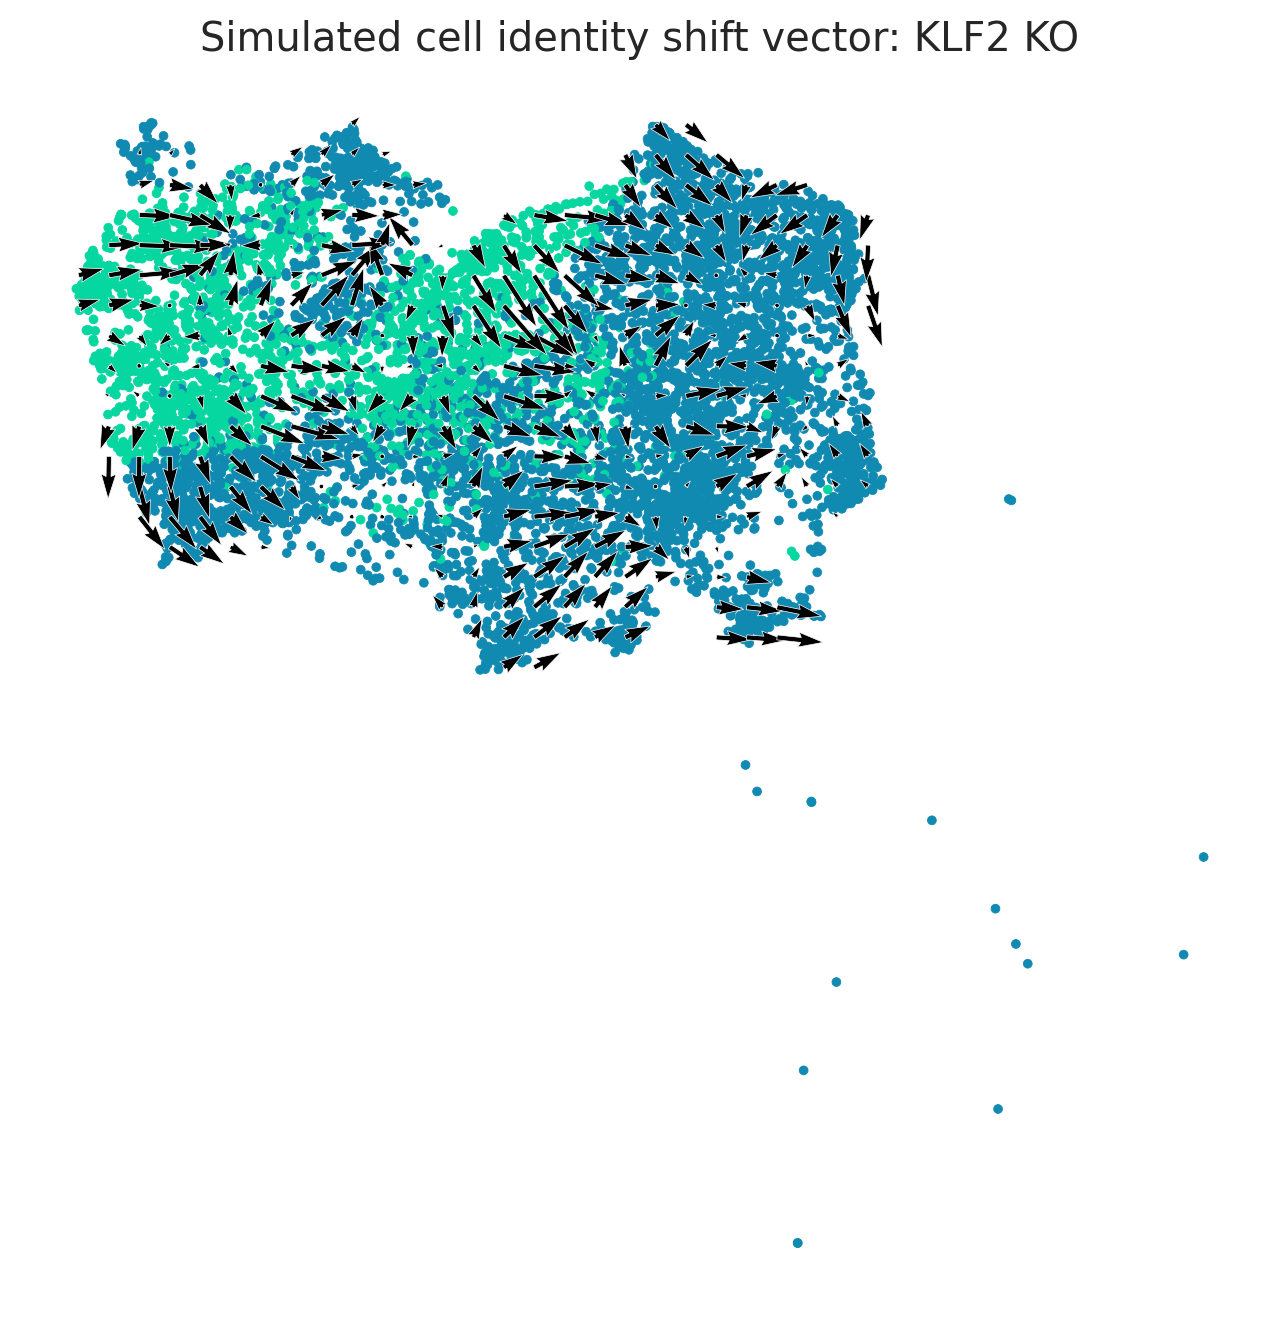

In [112]:
fig, ax = plt.subplots(figsize=[8, 8])
oracle_perturb.plot_cluster_whole(ax=ax, s=10)
oracle_perturb.plot_simulation_flow_on_grid(scale=scale_simulation, ax=ax, show_background=False)
title = f"Simulated cell identity shift vector: {goi} KO"
plt.title(title)
fig.savefig(f"{save_folder}/{goi}_oracle_perturb_quiver_on_grid_on_cluster_{goi}.pdf", bbox_inches='tight', dpi=300)


XBP1
NR3C1
KLF2
FOXO1
ATF3
ELF1
FOSL2
IKZF1
IRF1
BHLHE40


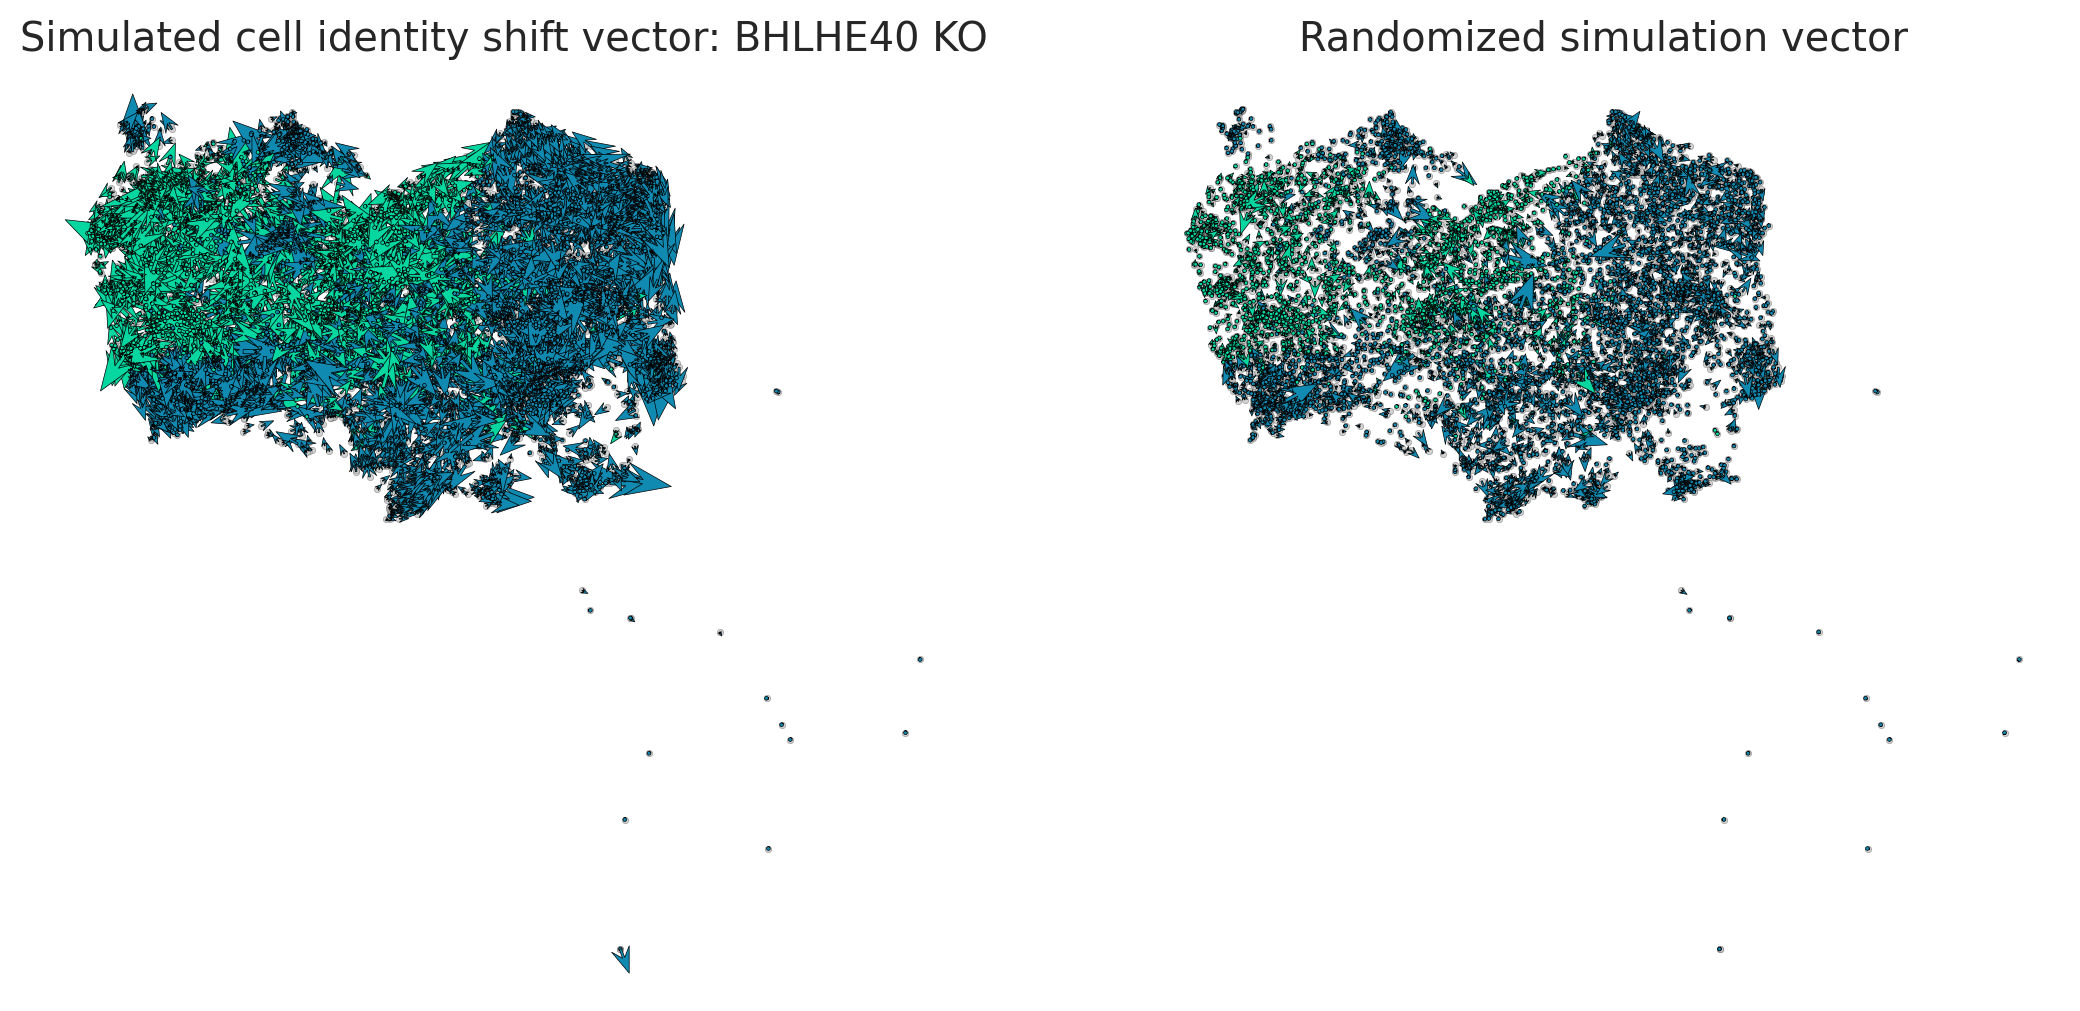

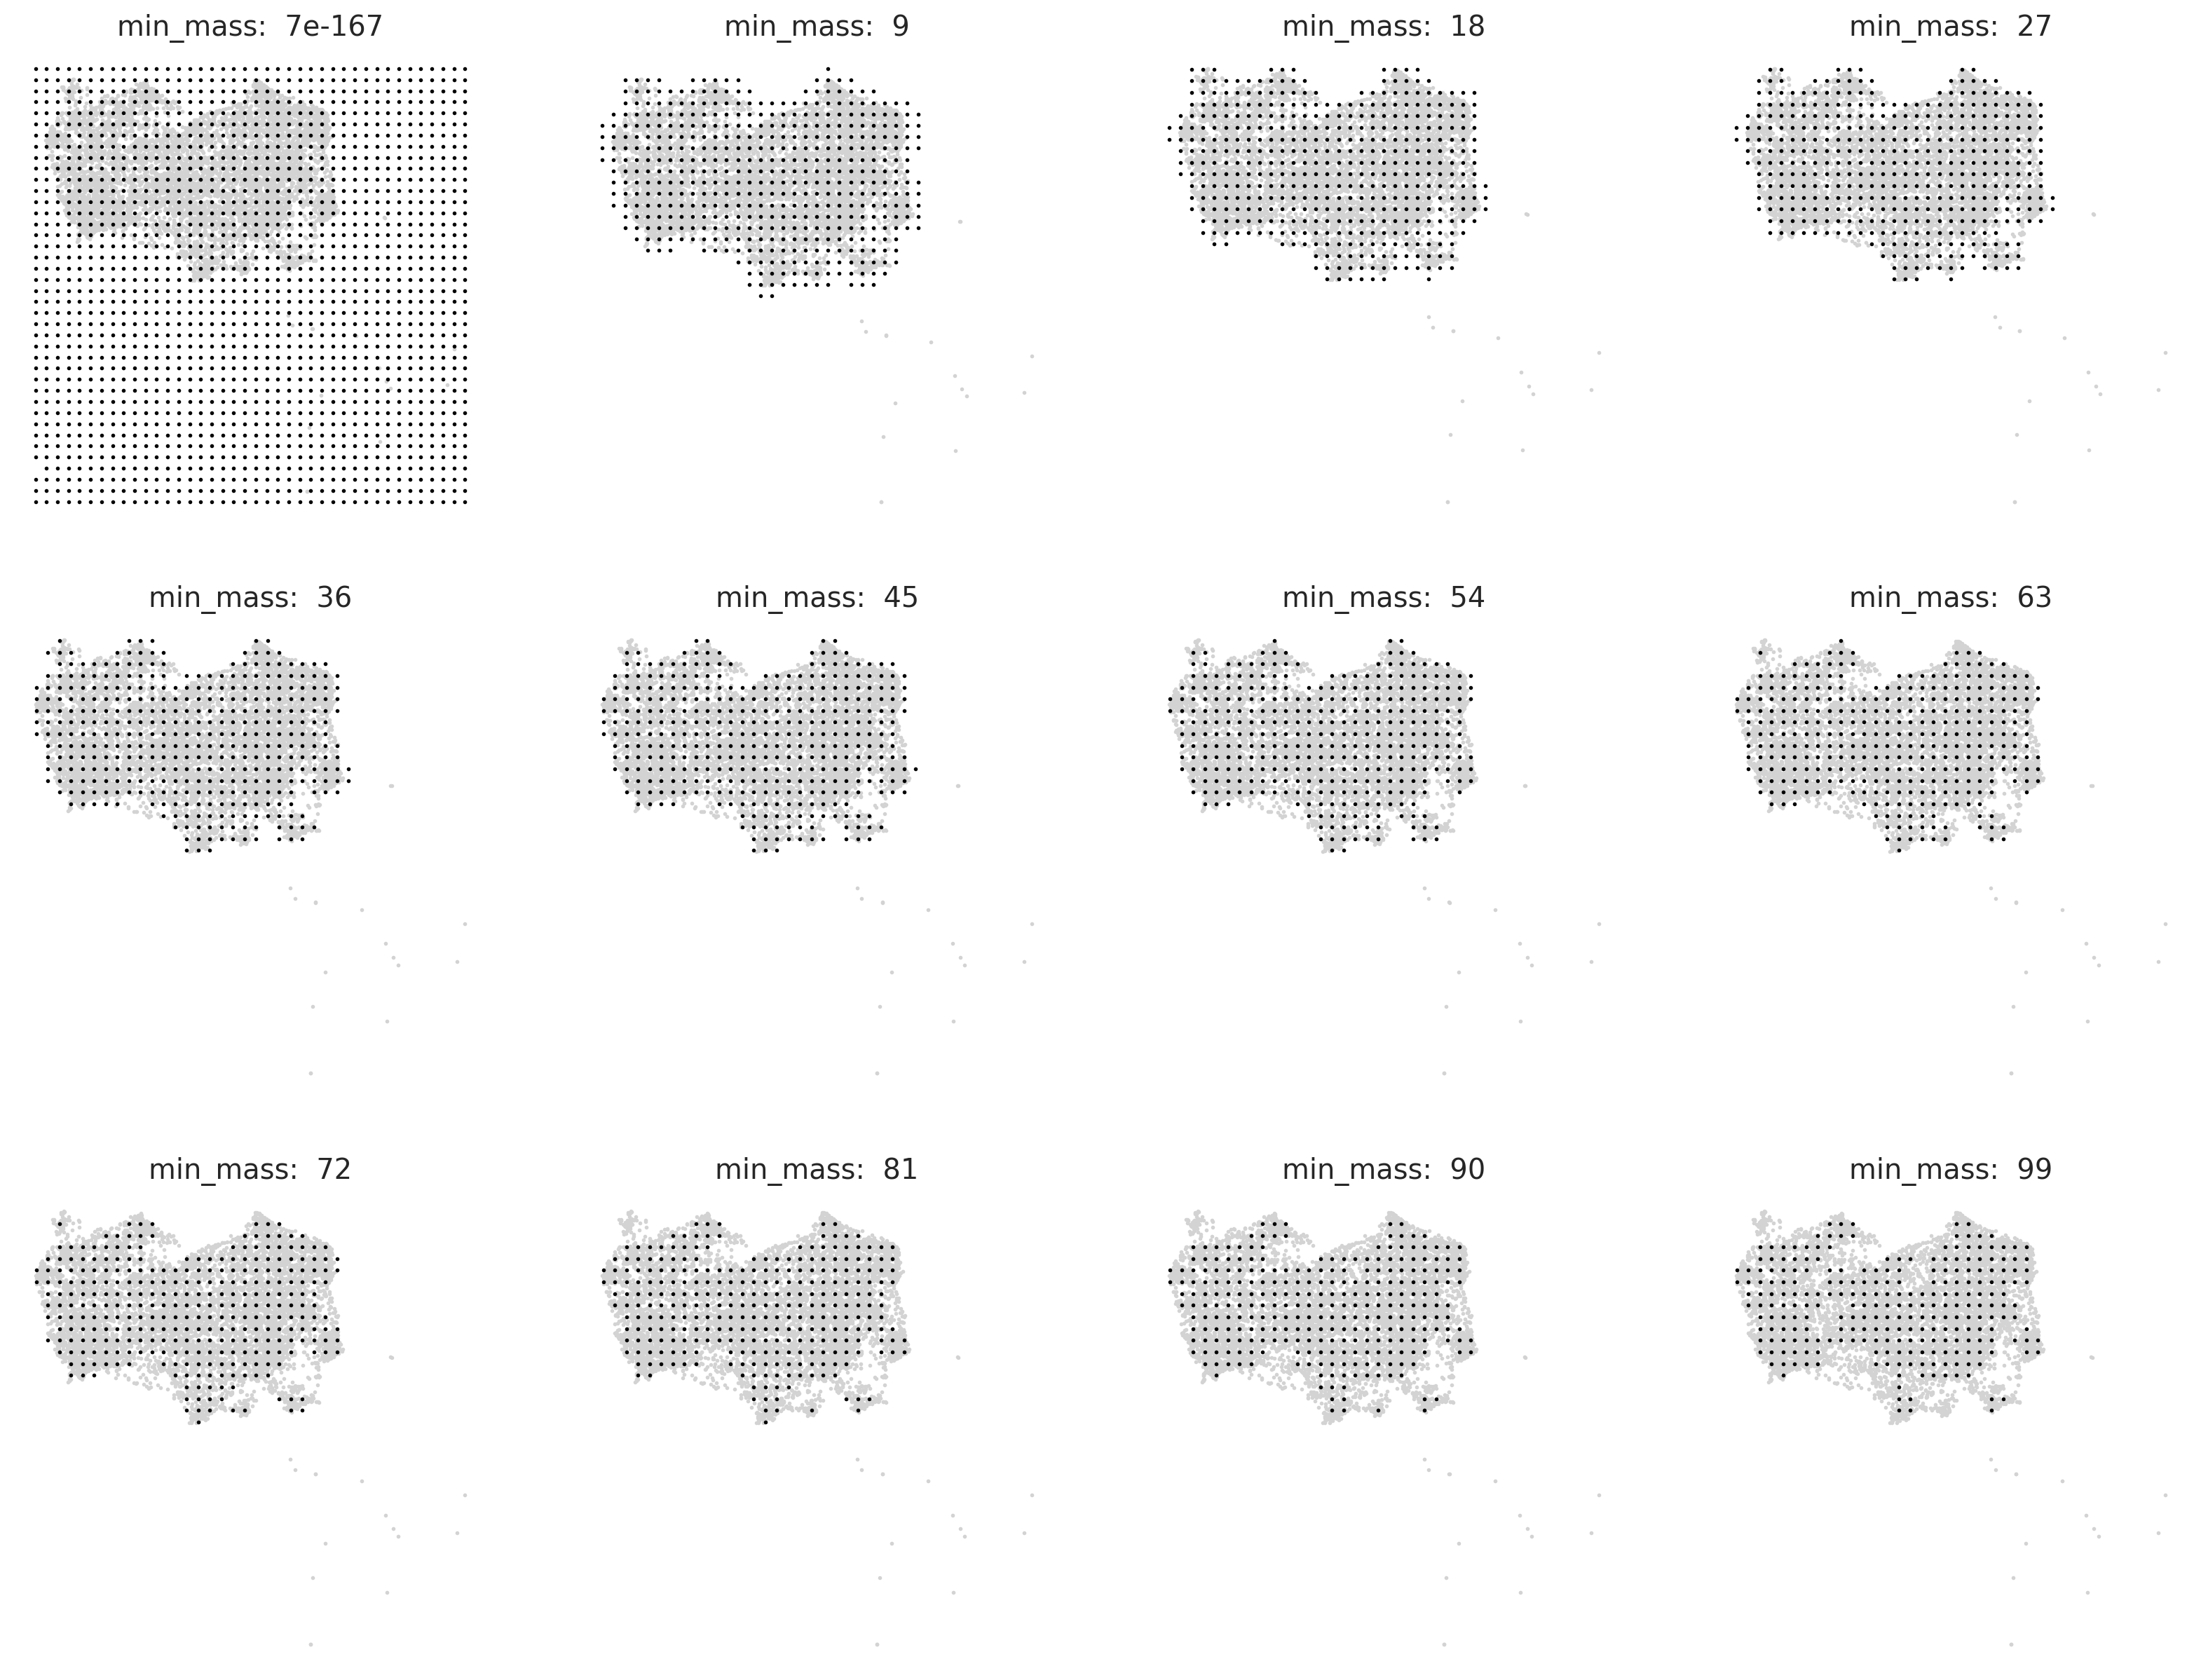

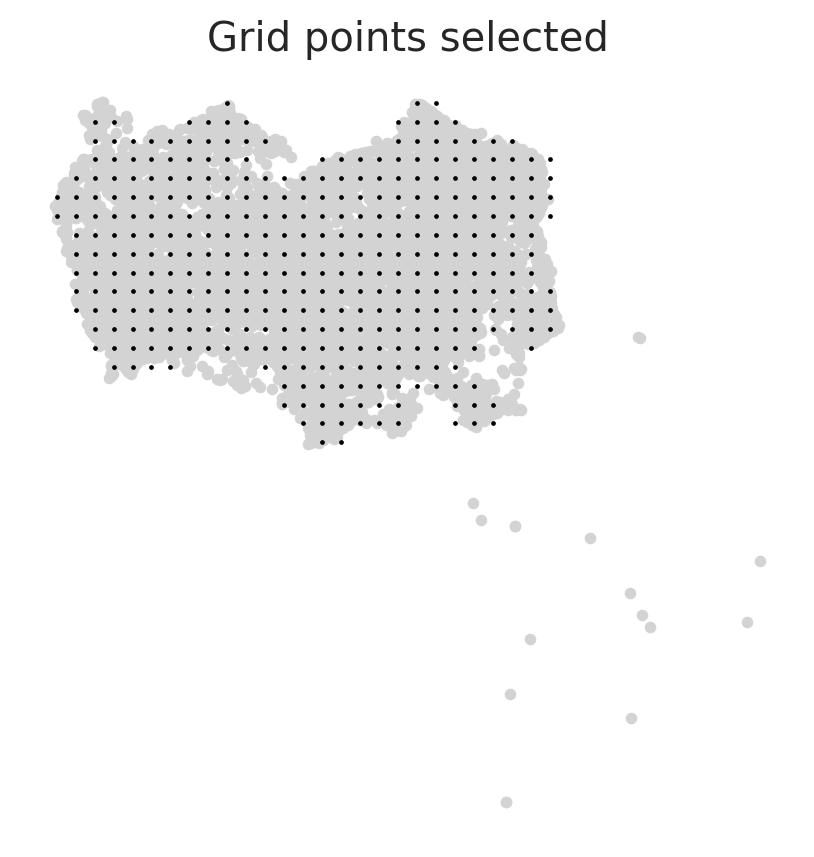

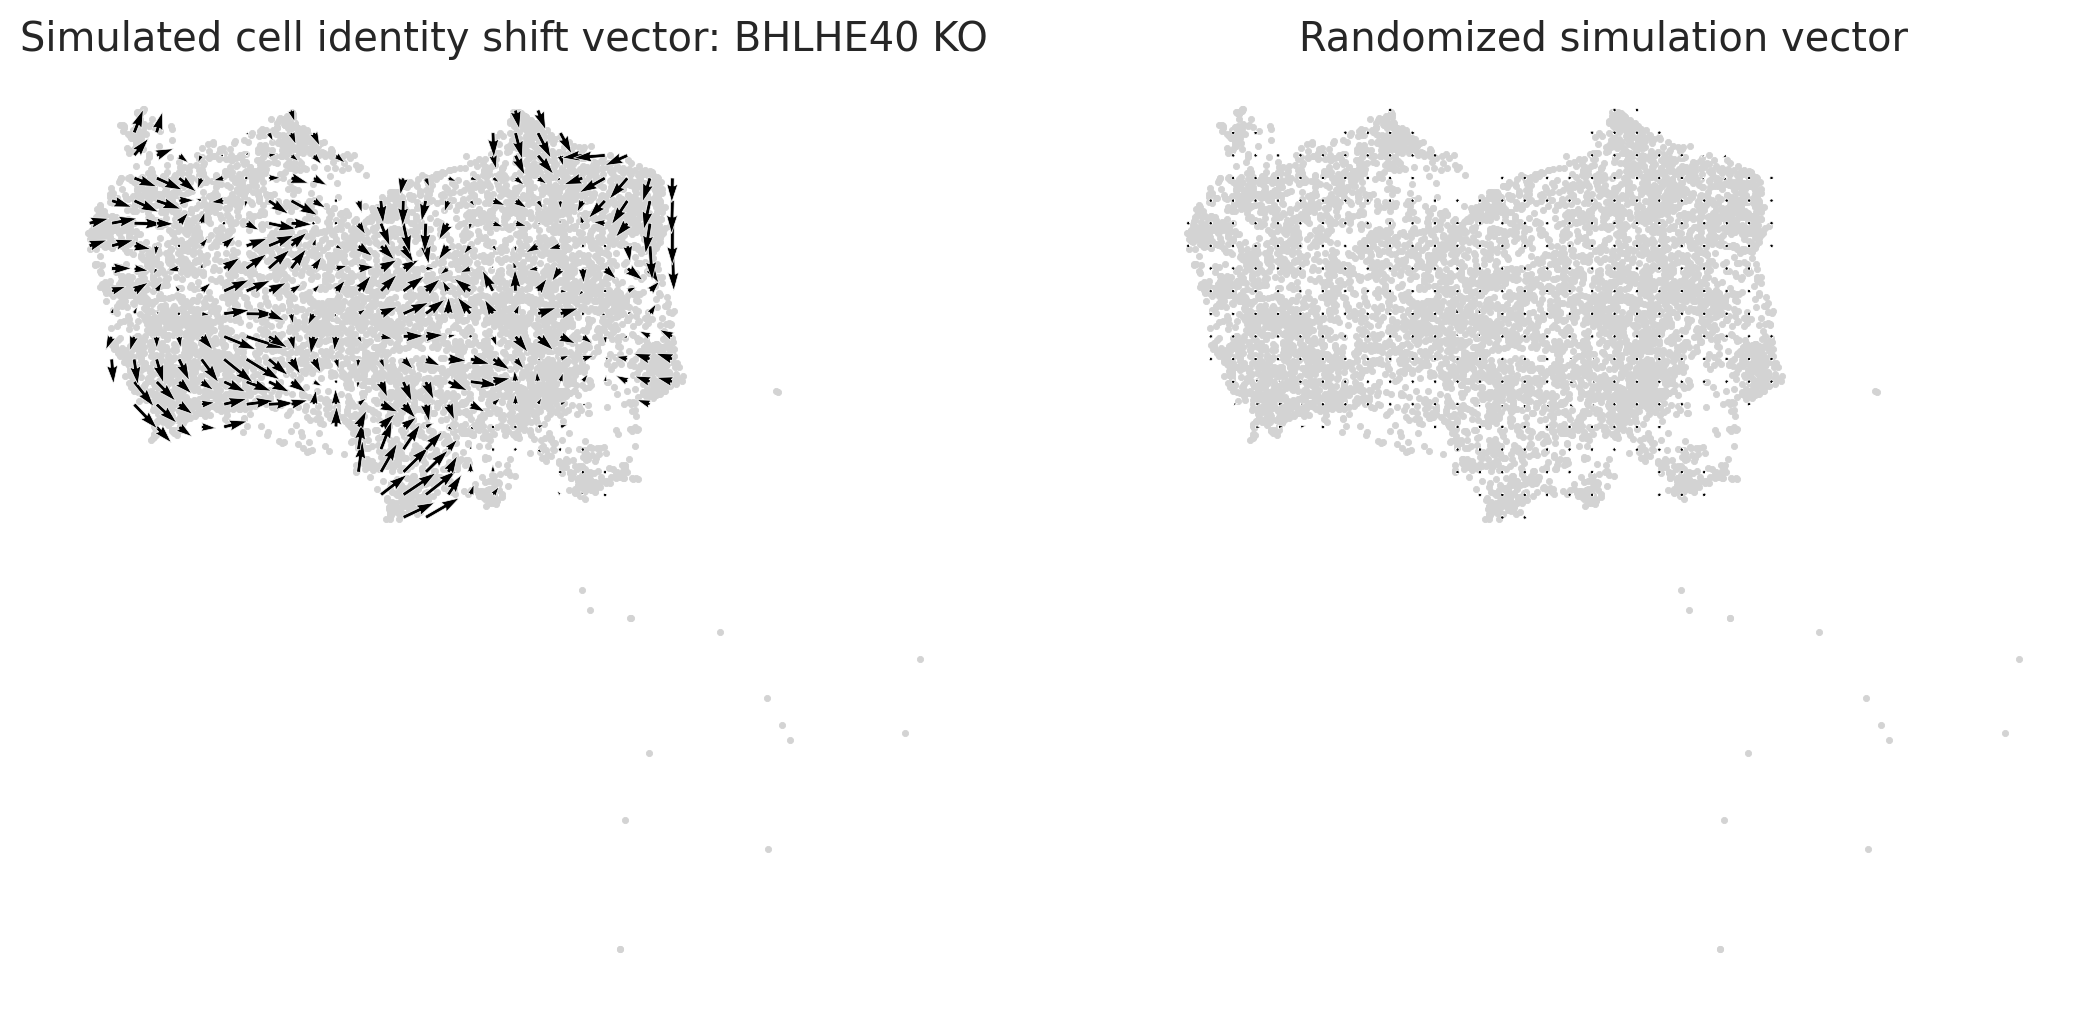

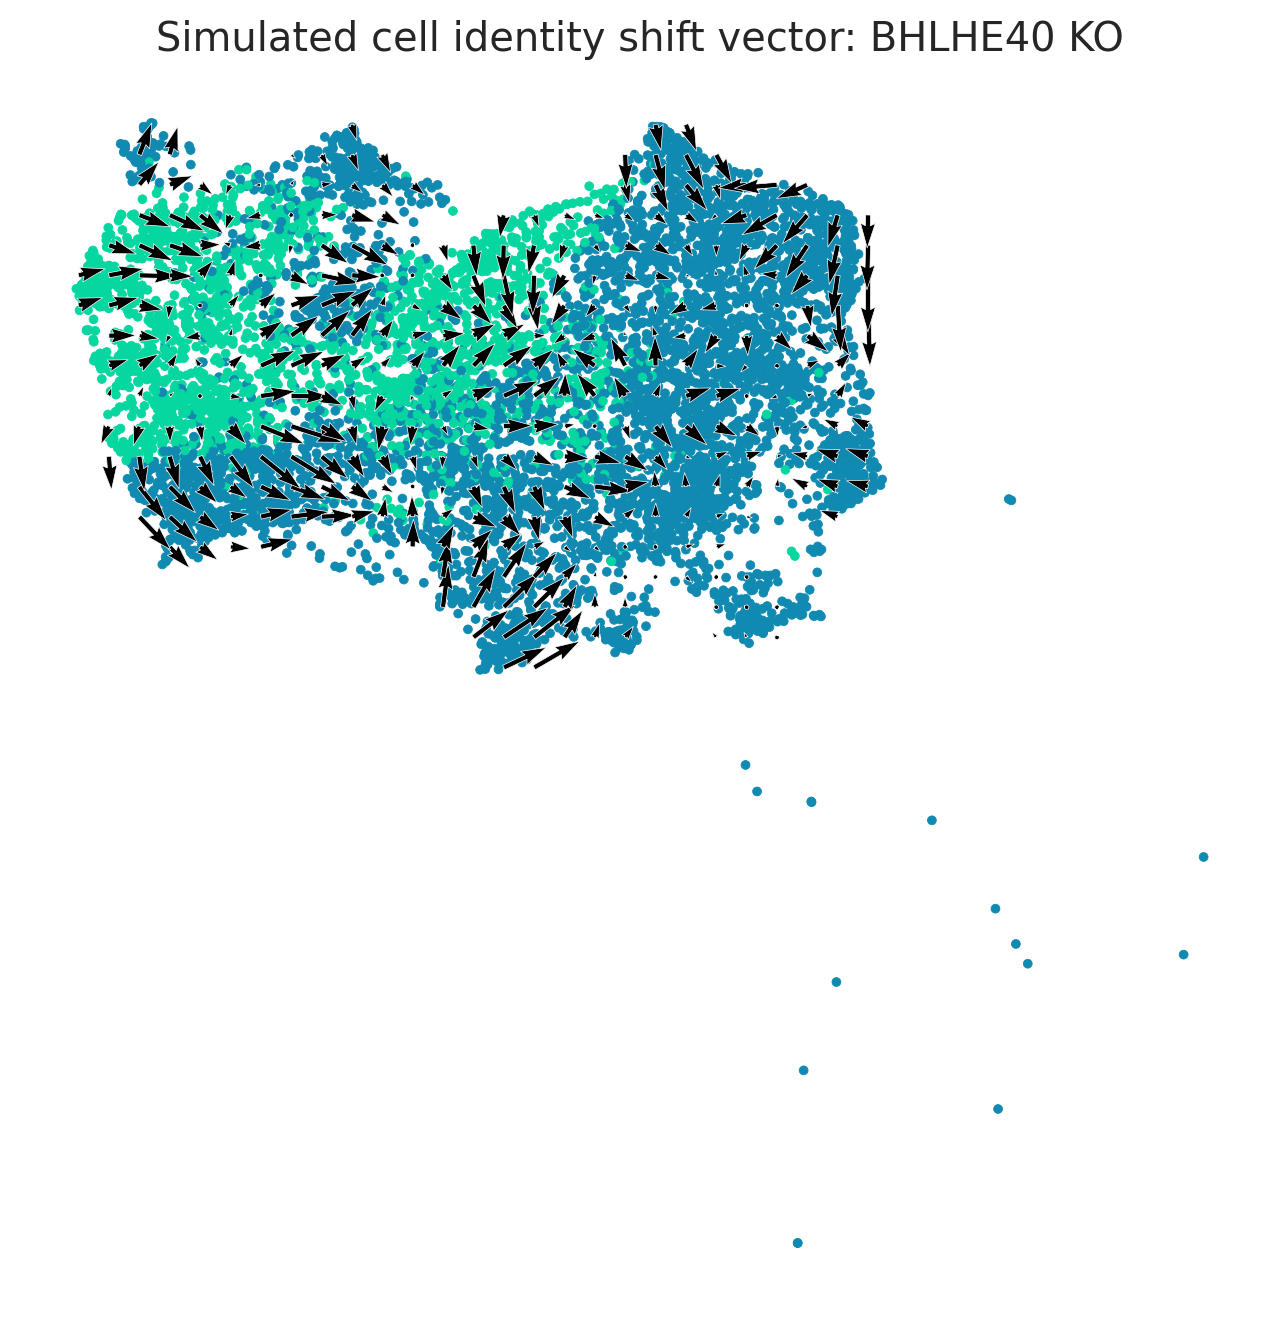

In [113]:
for goi in top_tf_each_cluster:
    print(goi)
    oracle_perturb = co.load_hdf5(goi + "_oracle_shifted.celloracle.oracle")
    %matplotlib inline

    fig, ax = plt.subplots(1, 2,  figsize=[13, 6])
    scale = 20
    # Show quiver plot
    oracle_perturb.plot_quiver(scale=scale, ax=ax[0])
    ax[0].set_title(f"Simulated cell identity shift vector: {goi} KO")

    # Show quiver plot that was calculated with randomized graph.
    oracle_perturb.plot_quiver_random(scale=scale, ax=ax[1])
    ax[1].set_title(f"Randomized simulation vector")
    fig.savefig(f"{save_folder}/oracle_perturb_quiver_{goi}.pdf", bbox_inches='tight', dpi=300)

    n_grid = 40
    oracle_perturb.calculate_p_mass(smooth=0.8, n_grid=n_grid, n_neighbors=200)
    oracle_perturb.suggest_mass_thresholds(n_suggestion=12)
    min_mass = 50
    oracle_perturb.calculate_mass_filter(min_mass=min_mass, plot=True)
    fig, ax = plt.subplots(1, 2,  figsize=[13, 6])

    scale_simulation = 7
    # Show quiver plot
    oracle_perturb.plot_simulation_flow_on_grid(scale=scale_simulation, ax=ax[0])
    ax[0].set_title(f"Simulated cell identity shift vector: {goi} KO")

    # Show quiver plot that was calculated with randomized graph.
    oracle_perturb.plot_simulation_flow_random_on_grid(scale=scale_simulation, ax=ax[1])
    ax[1].set_title(f"Randomized simulation vector")

    fig
    fig, ax = plt.subplots(figsize=[8, 8])
    oracle_perturb.plot_cluster_whole(ax=ax, s=10)
    oracle_perturb.plot_simulation_flow_on_grid(scale=scale_simulation, ax=ax, show_background=False)
    title = f"Simulated cell identity shift vector: {goi} KO"
    plt.title(title)
    fig.savefig(f"{save_folder}/{goi}_oracle_perturb_quiver_on_grid_on_cluster_{goi}.pdf", bbox_inches='tight', dpi=300)
